# 01 - Exploratory Data Analysis (EDA)
### Customer Churn Prediction in the Banking Sector

**Dataset:** [Credit Card customers - Kaggle](https://www.kaggle.com/datasets/anwarsan/credit-card-bank-churn)

This notebook covers:
1. Loading the raw dataset
2. Basic info, shape, dtypes, missing/unknown values
3. Target variable (`Attrition_Flag`) distribution (churn vs non-churn)
4. Distribution plots for quantitative features (to decide scaling method later)
5. Boxplots to spot outliers / narrow-range features
6. Categorical feature distributions
7. Correlation heatmap

Goal: understand the data well enough to design the preprocessing pipeline (notebook 02).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load the Dataset

In [4]:
DATA_PATH = "../data/raw/BankChurners.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [5]:
# Drop the last two Naive-Bayes helper columns (as done in the paper)
cols_to_drop = [c for c in df.columns if 'Naive_Bayes' in c]
print("Dropping columns:", cols_to_drop)

df = df.drop(columns=cols_to_drop)

# Drop CLIENTNUM later during preprocessing (kept here for EDA reference)
print("Shape after dropping helper columns:", df.shape)
df.head()


Dropping columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
Shape after dropping helper columns: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,NaN,NaN,NaN,739177606.333663,36903783.450231,708082083.0,713036770.5,717926358.0,773143533.0,828343083.0
Attrition_Flag,10127,2,Existing Customer,8500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,10127.0,NaN,NaN,NaN,46.32596,8.016814,26.0,41.0,46.0,52.0,73.0
Gender,10127,2,F,5358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,10127.0,NaN,NaN,NaN,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
Education_Level,10127,7,Graduate,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10127,4,Married,4687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,10127,6,Less than $40K,3561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,10127,4,Blue,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,10127.0,NaN,NaN,NaN,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0


In [8]:
# Standard missing-value check
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


In [9]:
# The dataset often encodes missing data as the string 'Unknown' instead of NaN
# (common in Education_Level, Marital_Status, Income_Category)
unknown_counts = (df == 'Unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0]
print("Columns containing 'Unknown' values:")
print(unknown_counts)


Columns containing 'Unknown' values:
Education_Level    1519
Marital_Status      749
Income_Category    1112
dtype: int64


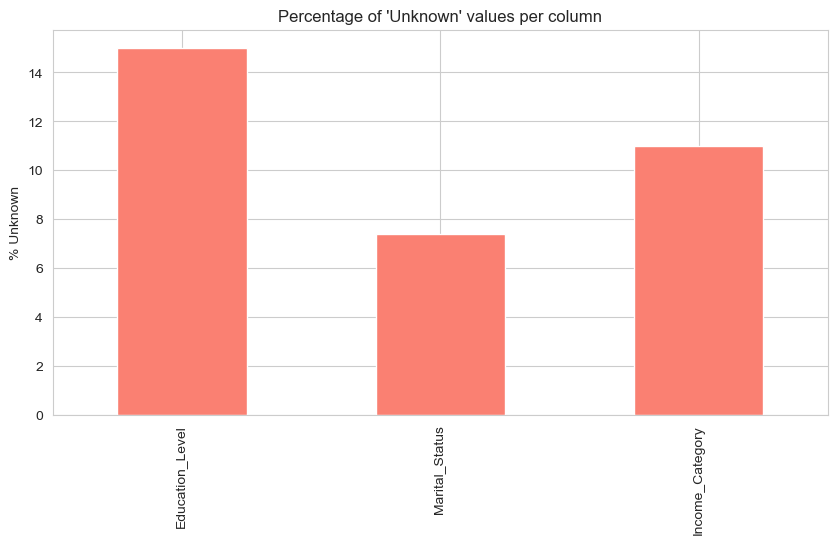

In [10]:
# Visualize proportion of 'Unknown' per affected column
if len(unknown_counts) > 0:
    (unknown_counts / len(df) * 100).plot(kind='bar', color='salmon')
    plt.ylabel('% Unknown')
    plt.title("Percentage of 'Unknown' values per column")
    plt.show()


Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


C:\Users\adity\AppData\Local\Temp\ipykernel_17300\3102558071.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition_Flag', data=df, ax=ax[0], palette='Set2')


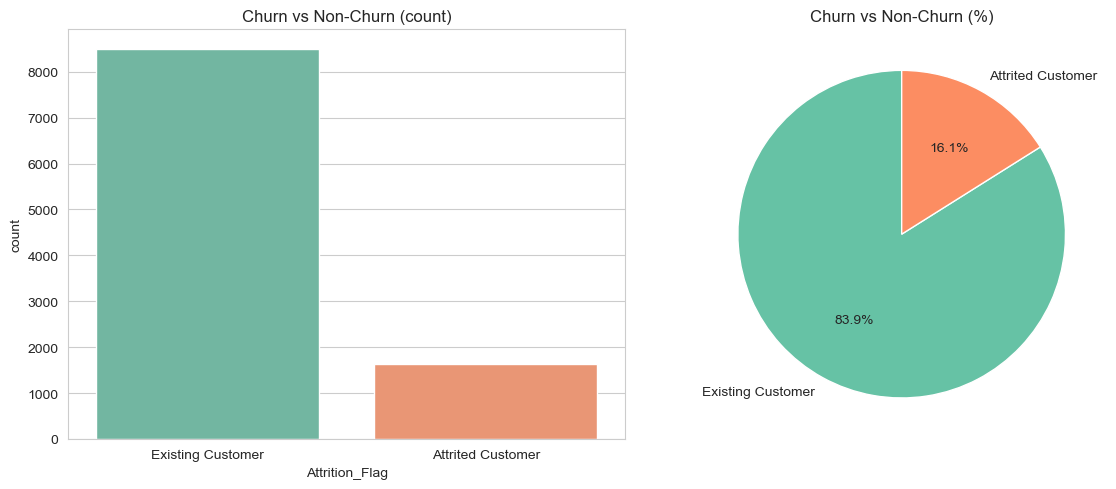

In [11]:
target_counts = df['Attrition_Flag'].value_counts()
target_pct = df['Attrition_Flag'].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Attrition_Flag', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Churn vs Non-Churn (count)')

ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
          colors=sns.color_palette('Set2'), startangle=90)
ax[1].set_title('Churn vs Non-Churn (%)')

plt.tight_layout()
plt.show()


**Observation:** The dataset is imbalanced (~16% churn vs ~84% non-churn, ratio roughly 1:5.4
as reported in the paper). This imbalance must be addressed before training models
(handled with SMOTE in notebook 03/04).


## 4. Quantitative Feature Distributions

We separate the quantitative columns and plot histograms to see which ones look
**normally distributed** (candidates for **standardization**) vs **skewed / wide-range**
(candidates for **normalization**) — this mirrors Table 2 in the paper.


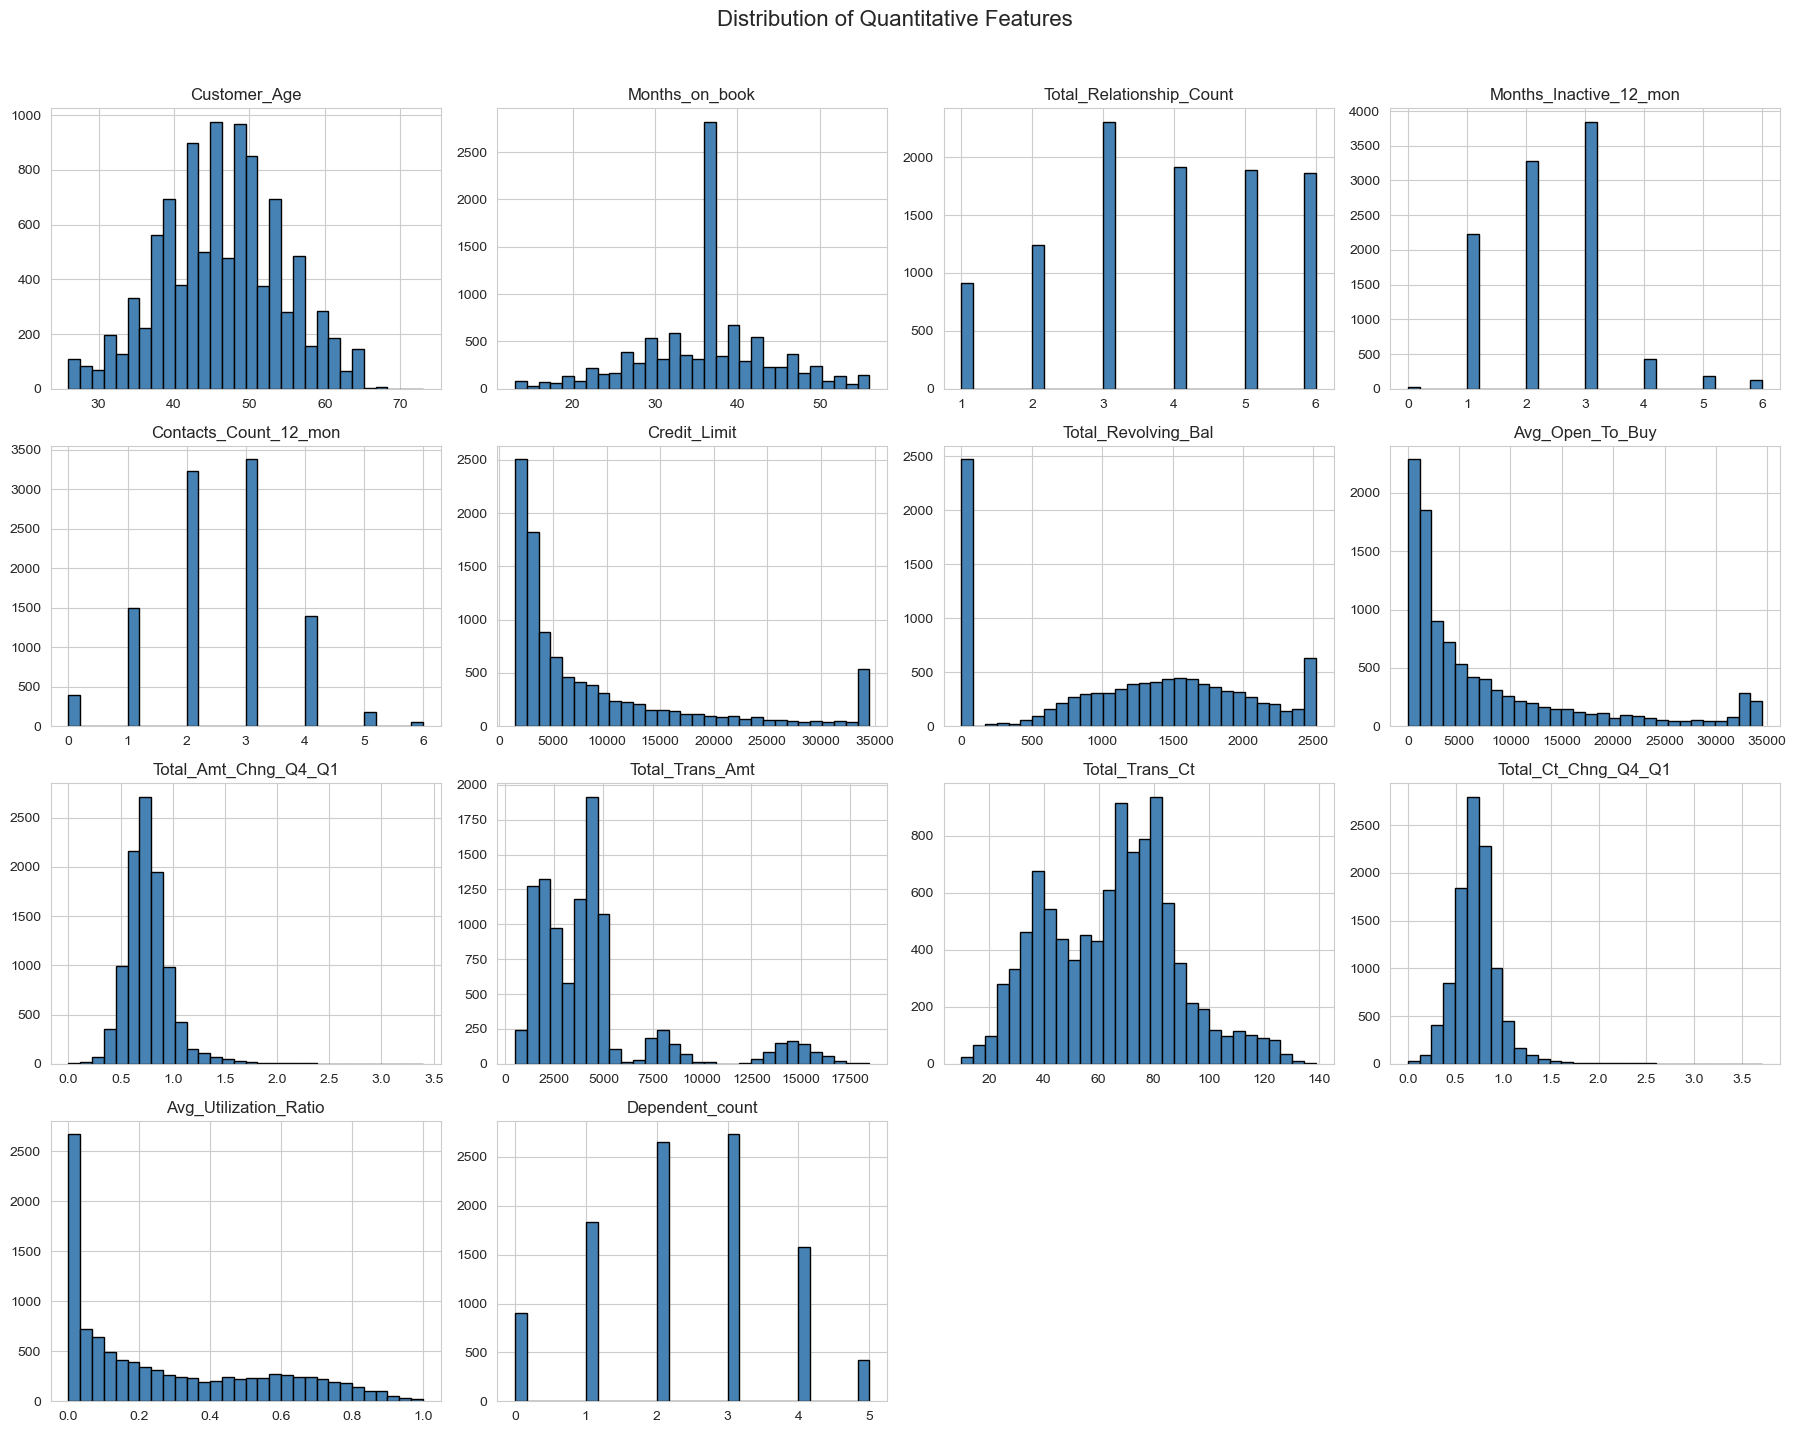

In [12]:
quant_cols = [
    'Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio', 'Dependent_count'
]

quant_cols = [c for c in quant_cols if c in df.columns]
df[quant_cols].hist(bins=30, figsize=(18, 14), color='steelblue', edgecolor='black')
plt.suptitle("Distribution of Quantitative Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


**Observation:**
- `Customer_Age` and `Months_on_book` look roughly **normally distributed** → standardization.
- `Credit_Limit`, `Avg_Open_To_Buy`, `Total_Revolving_Bal`, `Total_Trans_Amt`, `Total_Trans_Ct`
  have **wide/skewed ranges** → normalization.
- `Dependent_count`, `Total_Relationship_Count`, `Months_Inactive_12_mon`,
  `Contacts_Count_12_mon`, `Total_Amt_Chng_Q4_Q1`, `Total_Ct_Chng_Q4_Q1`,
  `Avg_Utilization_Ratio` have a **narrow range of variance** → leave unchanged.

(This matches Table 2 of the reference paper.)


## 5. Boxplots — Outlier Detection on Narrow-Range Features

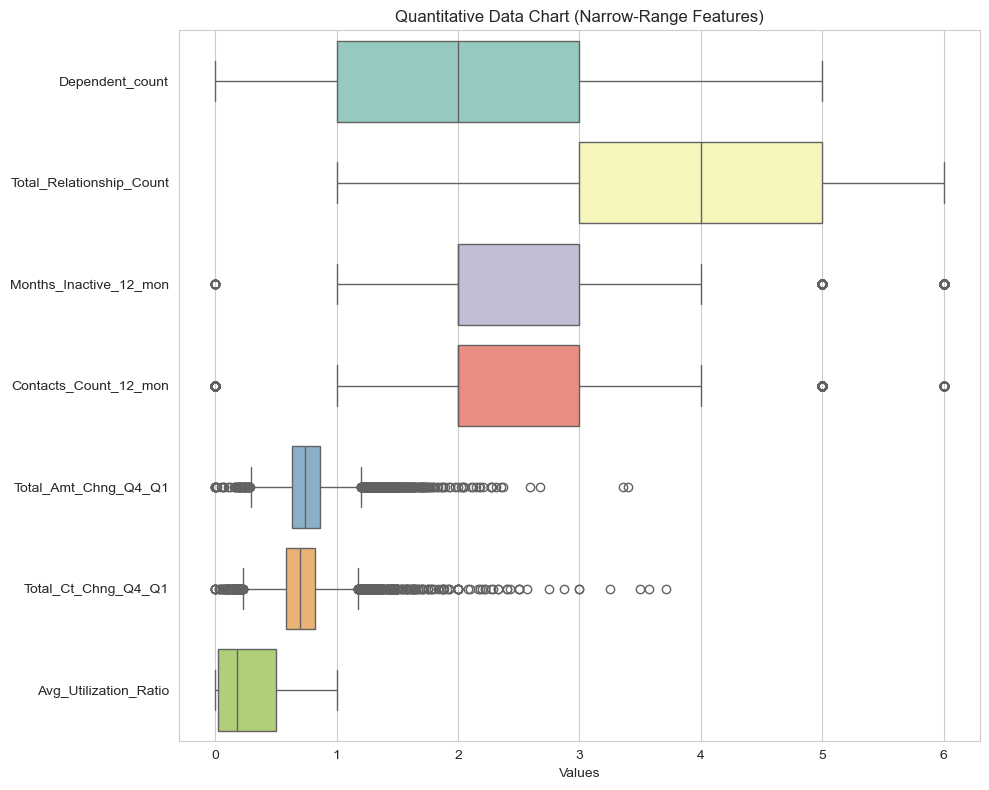

In [13]:
narrow_range_cols = [
    'Dependent_count', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio'
]
narrow_range_cols = [c for c in narrow_range_cols if c in df.columns]

plt.figure(figsize=(10, 8))
sns.boxplot(data=df[narrow_range_cols], orient='h', palette='Set3')
plt.title("Quantitative Data Chart (Narrow-Range Features)")
plt.xlabel("Values")
plt.tight_layout()
plt.show()


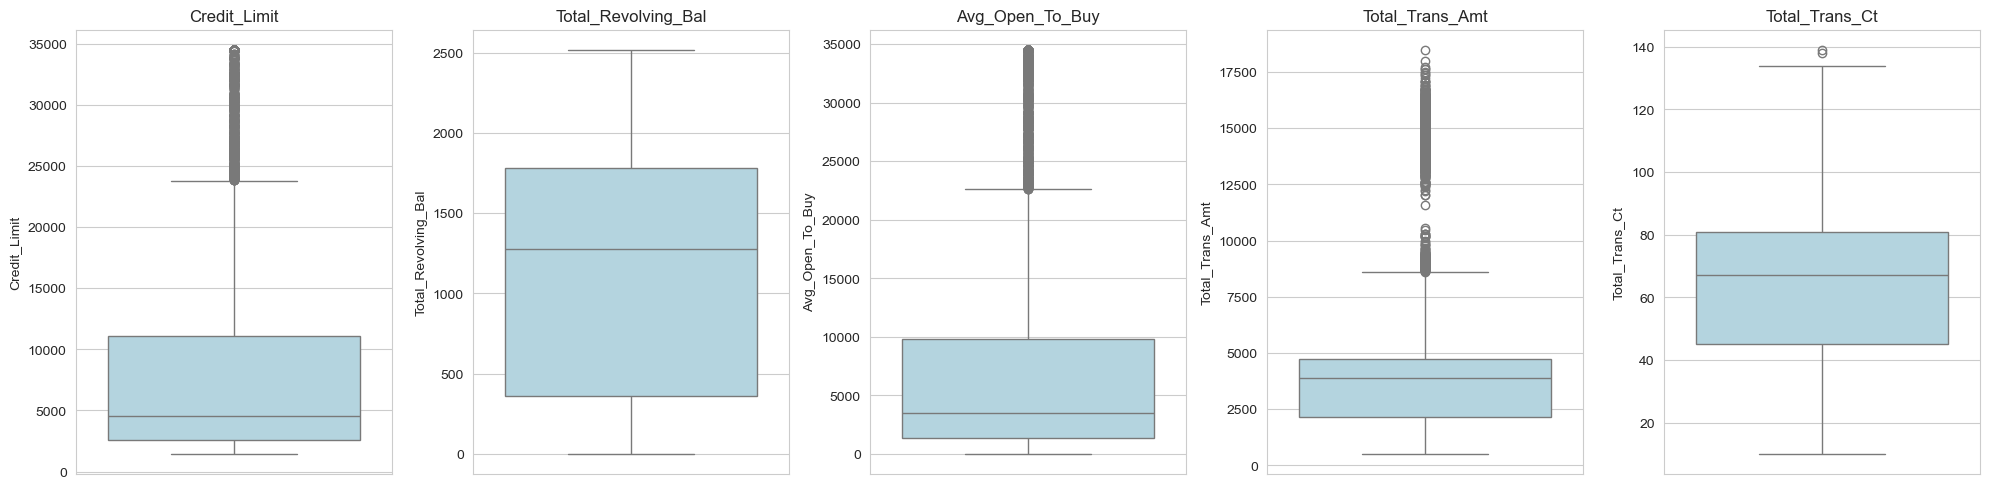

In [14]:
# Boxplots for the wide-range / skewed features
wide_range_cols = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
                    'Total_Trans_Amt', 'Total_Trans_Ct']
wide_range_cols = [c for c in wide_range_cols if c in df.columns]

fig, axes = plt.subplots(1, len(wide_range_cols), figsize=(20, 5))
for ax, col in zip(axes, wide_range_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. Categorical Feature Distributions

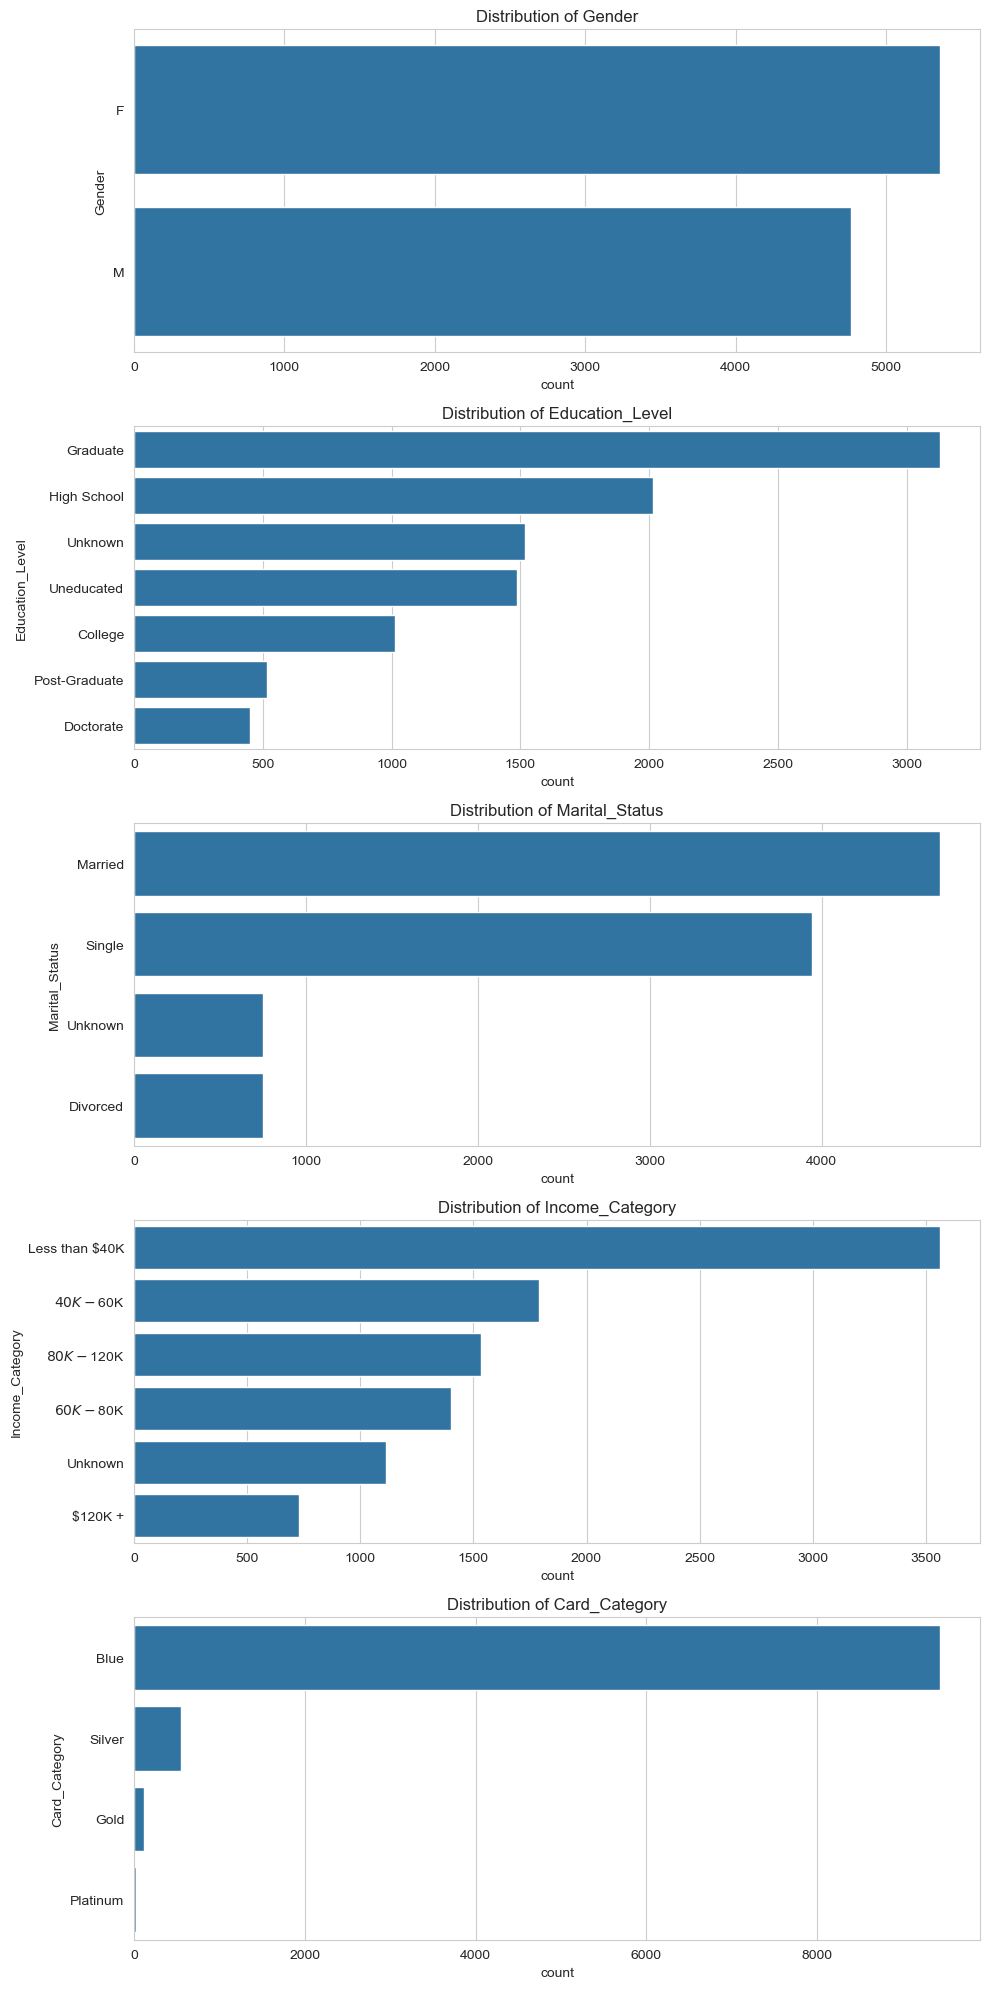

In [16]:
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


In [17]:
# Churn rate broken down by each categorical feature
for col in cat_cols:
    churn_rate = pd.crosstab(df[col], df['Attrition_Flag'], normalize='index') * 100
    print(f"\nChurn rate (%) by {col}:")
    print(churn_rate.round(2))



Churn rate (%) by Gender:
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                           17.36              82.64
M                           14.62              85.38

Churn rate (%) by Education_Level:
Attrition_Flag   Attrited Customer  Existing Customer
Education_Level                                      
College                      15.20              84.80
Doctorate                    21.06              78.94
Graduate                     15.57              84.43
High School                  15.20              84.80
Post-Graduate                17.83              82.17
Uneducated                   15.94              84.06
Unknown                      16.85              83.15

Churn rate (%) by Marital_Status:
Attrition_Flag  Attrited Customer  Existing Customer
Marital_Status                                      
Divorced                    16.18              83.82
Married                     15.13            

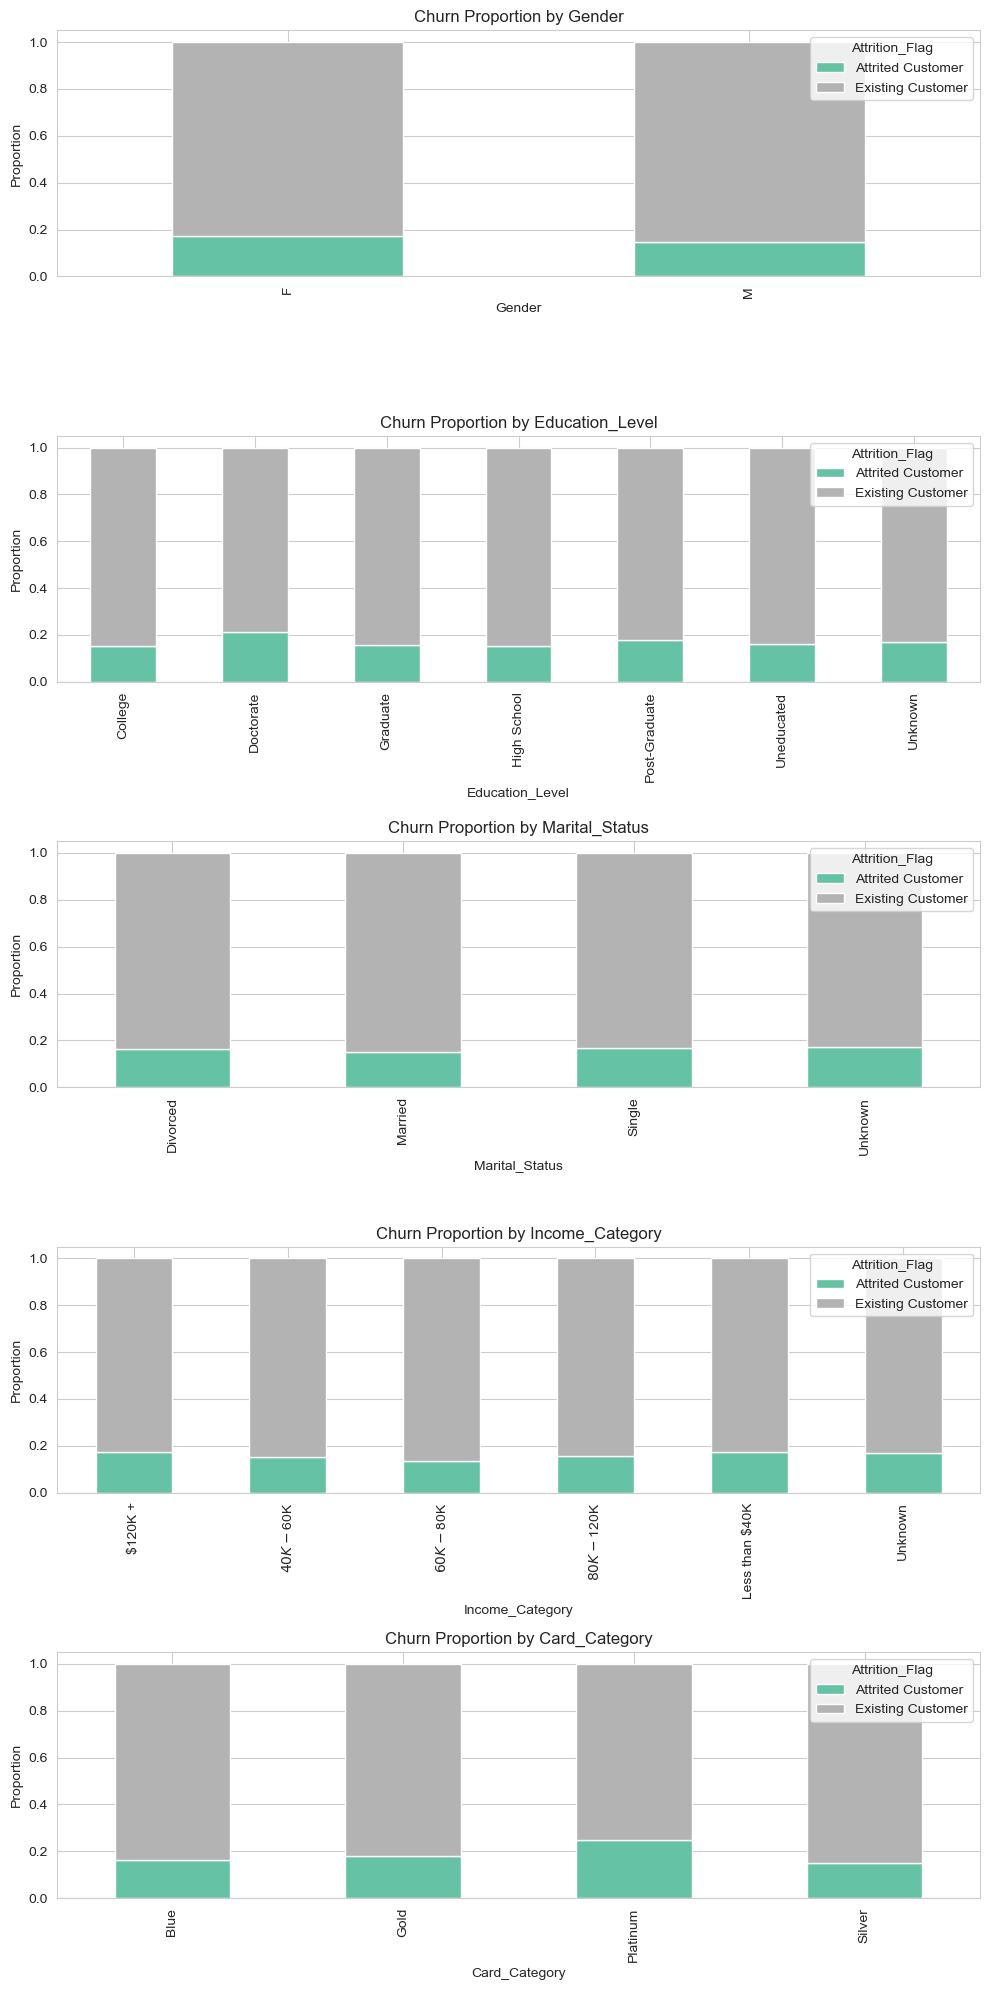

In [18]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    pd.crosstab(df[col], df['Attrition_Flag'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, colormap='Set2'
    )
    ax.set_title(f'Churn Proportion by {col}')
    ax.set_ylabel('Proportion')
    ax.legend(title='Attrition_Flag', loc='upper right')
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap (Numeric Features)

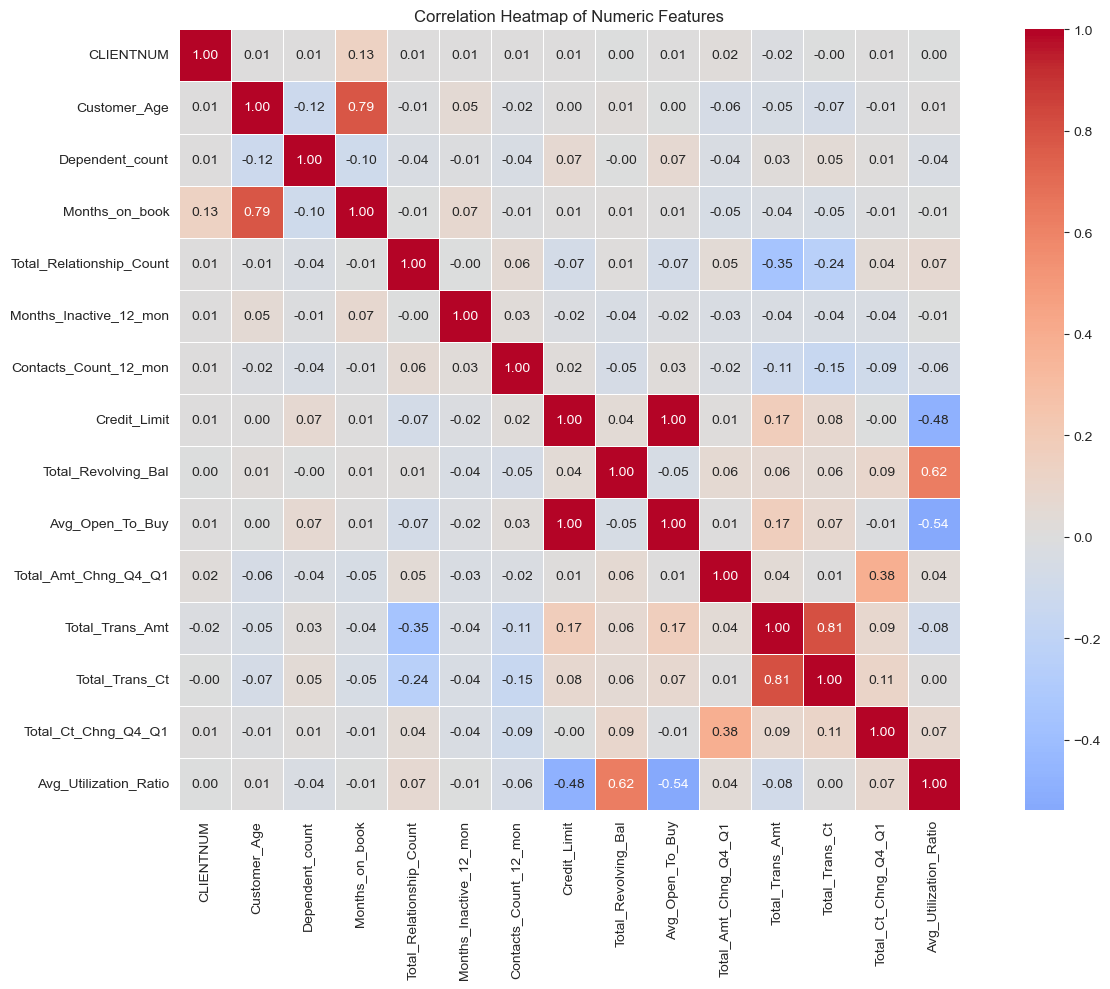

In [19]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


In [20]:
# Top correlated pairs (excluding self-correlation)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print("Top 10 most correlated feature pairs:")
print(corr_pairs.head(10))


Top 10 most correlated feature pairs:
Avg_Open_To_Buy        Credit_Limit             0.995981
Credit_Limit           Avg_Open_To_Buy          0.995981
Total_Trans_Amt        Total_Trans_Ct           0.807192
Total_Trans_Ct         Total_Trans_Amt          0.807192
Customer_Age           Months_on_book           0.788912
Months_on_book         Customer_Age             0.788912
Avg_Utilization_Ratio  Total_Revolving_Bal      0.624022
Total_Revolving_Bal    Avg_Utilization_Ratio    0.624022
Avg_Open_To_Buy        Avg_Utilization_Ratio    0.538808
Avg_Utilization_Ratio  Avg_Open_To_Buy          0.538808
dtype: float64


**Observation:** Features like `Credit_Limit` and `Avg_Open_To_Buy` are likely highly
correlated (since Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal). This is useful
to know for feature selection / multicollinearity checks later.


## 8. EDA Summary & Next Steps

**Key takeaways:**
- Target is imbalanced (~84% stay vs ~16% churn) → need SMOTE.
- `Unknown` values exist in some categorical columns → need cleaning.
- `Customer_Age` & `Months_on_book` ≈ normal distribution → standardize.
- Several quantitative features are wide-range/skewed → normalize.
- A few quantitative features have narrow variance → leave unchanged.
- Categorical features have 2 values (Gender) or many values (Education_Level,
  Marital_Status, Income_Category, Card_Category) → label encoding vs one-hot encoding
  respectively.
- `Credit_Limit` and `Avg_Open_To_Buy` are strongly correlated — worth keeping in mind.

➡️ **Next:** `02_preprocessing.ipynb` — clean unknowns, encode categoricals, scale
quantitative features, and prepare the final modeling dataset.
